<a href="https://colab.research.google.com/github/Danial9218/Python-/blob/main/NS_Domashnee_zadanie_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Домашнее задание №1
Определение тональности отзывов на фильмы с сайта IMDB
- IMDB обзоры фильмов классификация настроений
- Dataset состоит из 2х кортежей:
x_train, x_test: список последовательностей, которые являются списками индексов (целых чисел). Каждый из наборов данных состоят из 25 000 обзоров фильмов из IMDB, с указанием тональности (положительным/отрицательным). Обзоры были предварительно обработаны, и каждый обзор кодируется как последовательность индексов слов (целых чисел). Для удобства слова индексируются по общей частоте в наборе данных, так что, например, целое число " 3 " кодирует 3-е наиболее частое слово в данных.
- Как правило, "0" не обозначает конкретное слово, а вместо этого используется для кодирования любого неизвестного слова.
y_train, y_test: список целых меток (1 - положительная или 0 - отрицательная тональность).

Раскодируем сообщения

Служебные коды:  
0 - символ заполнитель  
1 - начало последовательности  
2 - неизвестное слово  

#Задание
- 1) Обучить нейронную сеть (Dense и SimpleRNN) подобрав структуру для классификации тональности отзывов.
-2) Сравнить результат их работы на тестовой выборке.
-3) Выбрать два отзыва с сайта https://www.imdb.com/ к любым фильмам. Один отрицательный и один положительный.
-4) Подготовить данные и протестировать на нейронных сетях.

# В отчет
- программа
-структуры сетей
- графики обучения
- адрес с выбранными для тестирования отзывами
- код и результат тестирования выбранных отзывов

In [ ]:
from keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Embedding, SimpleRNN
from tensorflow.keras import utils
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
import matplotlib.pyplot as plt

## Загружаем данные

Данные подготовлены для максимального количества слов 20000.

In [ ]:
num_words=20000

In [ ]:
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=num_words)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
len(x_train)

25000

## Просмотр данных

In [ ]:
index = 3
print(x_train[index])
print(y_train[index])

[1, 4, 18609, 16085, 33, 2804, 4, 2040, 432, 111, 153, 103, 4, 1494, 13, 70, 131, 67, 11, 61, 15305, 744, 35, 3715, 761, 61, 5766, 452, 9214, 4, 985, 7, 2, 59, 166, 4, 105, 216, 1239, 41, 1797, 9, 15, 7, 35, 744, 2413, 31, 8, 4, 687, 23, 4, 2, 7339, 6, 3693, 42, 38, 39, 121, 59, 456, 10, 10, 7, 265, 12, 575, 111, 153, 159, 59, 16, 1447, 21, 25, 586, 482, 39, 4, 96, 59, 716, 12, 4, 172, 65, 9, 579, 11, 6004, 4, 1615, 5, 2, 7, 5168, 17, 13, 7064, 12, 19, 6, 464, 31, 314, 11, 2, 6, 719, 605, 11, 8, 202, 27, 310, 4, 3772, 3501, 8, 2722, 58, 10, 10, 537, 2116, 180, 40, 14, 413, 173, 7, 263, 112, 37, 152, 377, 4, 537, 263, 846, 579, 178, 54, 75, 71, 476, 36, 413, 263, 2504, 182, 5, 17, 75, 2306, 922, 36, 279, 131, 2895, 17, 2867, 42, 17, 35, 921, 18435, 192, 5, 1219, 3890, 19, 2, 217, 4122, 1710, 537, 2, 1236, 5, 736, 10, 10, 61, 403, 9, 2, 40, 61, 4494, 5, 27, 4494, 159, 90, 263, 2311, 4319, 309, 8, 178, 5, 82, 4319, 4, 65, 15, 9225, 145, 143, 5122, 12, 7039, 537, 746, 537, 537, 15, 7979, 4

In [ ]:
# загрузка словаря, где ключи - слова, а значения - частота использования слова
word_index = imdb.get_word_index()

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
word_index

{'fawn': 34701,
 'tsukino': 52006,
 'nunnery': 52007,
 'sonja': 16816,
 'vani': 63951,
 'woods': 1408,
 'spiders': 16115,
 'hanging': 2345,
 'woody': 2289,
 'trawling': 52008,
 "hold's": 52009,
 'comically': 11307,
 'localized': 40830,
 'disobeying': 30568,
 "'royale": 52010,
 "harpo's": 40831,
 'canet': 52011,
 'aileen': 19313,
 'acurately': 52012,
 "diplomat's": 52013,
 'rickman': 25242,
 'arranged': 6746,
 'rumbustious': 52014,
 'familiarness': 52015,
 "spider'": 52016,
 'hahahah': 68804,
 "wood'": 52017,
 'transvestism': 40833,
 "hangin'": 34702,
 'bringing': 2338,
 'seamier': 40834,
 'wooded': 34703,
 'bravora': 52018,
 'grueling': 16817,
 'wooden': 1636,
 'wednesday': 16818,
 "'prix": 52019,
 'altagracia': 34704,
 'circuitry': 52020,
 'crotch': 11585,
 'busybody': 57766,
 "tart'n'tangy": 52021,
 'burgade': 14129,
 'thrace': 52023,
 "tom's": 11038,
 'snuggles': 52025,
 'francesco': 29114,
 'complainers': 52027,
 'templarios': 52125,
 '272': 40835,
 '273': 52028,
 'zaniacs': 52130,

In [ ]:
# подготовка словаря, где ключи - частота использования слова, а значения - слова
reverse_word_index = {}
for key, value in word_index.items():
  reverse_word_index[value] = key

In [ ]:
reverse_word_index

{34701: 'fawn',
 52006: 'tsukino',
 52007: 'nunnery',
 16816: 'sonja',
 63951: 'vani',
 1408: 'woods',
 16115: 'spiders',
 2345: 'hanging',
 2289: 'woody',
 52008: 'trawling',
 52009: "hold's",
 11307: 'comically',
 40830: 'localized',
 30568: 'disobeying',
 52010: "'royale",
 40831: "harpo's",
 52011: 'canet',
 19313: 'aileen',
 52012: 'acurately',
 52013: "diplomat's",
 25242: 'rickman',
 6746: 'arranged',
 52014: 'rumbustious',
 52015: 'familiarness',
 52016: "spider'",
 68804: 'hahahah',
 52017: "wood'",
 40833: 'transvestism',
 34702: "hangin'",
 2338: 'bringing',
 40834: 'seamier',
 34703: 'wooded',
 52018: 'bravora',
 16817: 'grueling',
 1636: 'wooden',
 16818: 'wednesday',
 52019: "'prix",
 34704: 'altagracia',
 52020: 'circuitry',
 11585: 'crotch',
 57766: 'busybody',
 52021: "tart'n'tangy",
 14129: 'burgade',
 52023: 'thrace',
 11038: "tom's",
 52025: 'snuggles',
 29114: 'francesco',
 52027: 'complainers',
 52125: 'templarios',
 40835: '272',
 52028: '273',
 52130: 'zaniacs',

In [ ]:
reverse_word_index[202]

'own'

In [ ]:
reverse_word_index[205-3]

'own'

In [ ]:
index = 1000
message = ''
for code in x_train[index]:
    word = reverse_word_index.get(code - 3, '?')
    message += word + ' '
print(x_train[index])
message

[1, 261, 13, 69, 110, 15394, 11, 6, 750, 96, 145, 11, 2, 13, 426, 377, 233, 7, 4, 114, 549, 18, 3482, 1218, 7, 3199, 2102, 620, 5, 997, 429, 6, 4157, 7, 1654, 3404, 5, 1387, 2795, 4, 277, 10, 10, 103, 886, 49, 7, 4, 85, 857, 13, 1637, 56, 6, 1039, 7, 4, 4700, 626, 288, 8, 280, 174, 2541, 4, 182, 7, 15394, 10, 10, 12, 505, 46, 14, 9, 31, 7, 148, 108, 1055, 315, 4, 7423, 15, 62, 140, 2555, 8, 374, 639, 4, 22, 381, 5810, 13216, 3199, 2102, 17, 4409, 2, 12982, 46, 7, 4, 1336, 8, 17403, 4, 2952, 7, 2, 8, 2541, 5, 2363, 1176, 4, 500, 6, 12578, 2, 15240, 34, 4, 4698, 37, 9090, 27, 84, 34, 4578, 51, 934, 40, 2, 671, 4, 3359, 7, 4, 1973, 2290, 4, 323, 1650, 4824, 1510, 4409, 9, 4415, 11, 4, 1647, 1733, 34, 2549, 2, 37, 115, 2466, 42, 889, 4, 313, 280, 4415, 497, 8, 3890, 11, 19, 4, 5751, 34, 1658, 6, 1927, 767, 18546, 19, 2, 7, 1336, 5, 428, 2964, 8, 135, 2, 659, 309, 620, 5, 997, 18, 27, 113, 367, 4, 1654, 1986, 7, 2, 23, 27, 96, 8, 6, 1304, 19, 4205, 5, 4, 500, 10, 10, 323, 3199, 2102, 16, 18

"? although i had seen gymkata in a theater way back in ? i couldn't remember anything of the plot except for vague images of kurt thomas running and fighting against a backdrop of stone walls and disappointment regarding the ending br br after reading some of the other reviews i picked up a copy of the newly released dvd to once again enter the world of gymkata br br it turns out this is one of those films produced during the '80s that would go directly to video today the film stars champion gymnast kurt thomas as jonathan ? recruited out of the blue to infiltrate the nation of ? to enter and hopefully win the game a suicidal ? sponsored by the khan who encourages his people by yelling what sounds like ? power the goal of the mission involves the star wars defense system jonathan is trained in the martial arts by princess ? who never speaks or leaves the house once trained tries to blend in with the locals by wearing a bright red sweater with ? of blue and white needless to say ? find

In [ ]:
y_train[index]

np.int64(0)

## Подготовка данных для нейронной сети

In [ ]:
maxlen = 200

In [ ]:
x_train = pad_sequences(x_train, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)

## Создание нейронной сети

In [ ]:
model = Sequential()
model.add(Embedding(num_words, 50, input_length=maxlen))
model.add(Flatten())
model.add(Dense(5))
model.add(Dense(1, activation='sigmoid'))

In [ ]:
model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
model_SimpleRNN = Sequential()
model_SimpleRNN.add(Embedding(num_words, 50, input_length=maxlen))
model_SimpleRNN.add(SimpleRNN(3))
model_SimpleRNN.add(Dense(1, activation='sigmoid'))

In [ ]:
model_SimpleRNN.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['accuracy'])

## Обучаем нейронную сеть

In [ ]:
history_dence = model.fit(x_train,
                    y_train,
                    epochs=3,
                    batch_size=32,
                    validation_split=0.1)

Epoch 1/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.7700 - loss: 0.4618 - val_accuracy: 0.8636 - val_loss: 0.3296
Epoch 2/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9075 - loss: 0.2311 - val_accuracy: 0.8480 - val_loss: 0.3706
Epoch 3/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9712 - loss: 0.0898 - val_accuracy: 0.8568 - val_loss: 0.4260


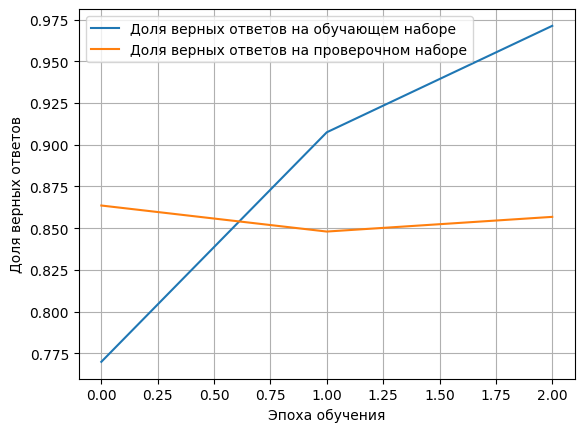

In [ ]:
plt.plot(history_dence.history['accuracy'],
         label='Доля верных ответов на обучающем наборе')
plt.plot(history_dence.history['val_accuracy'],
         label='Доля верных ответов на проверочном наборе')
plt.xlabel('Эпоха обучения')
plt.ylabel('Доля верных ответов')
plt.legend()
plt.grid()
plt.show()

In [ ]:
history_SimpleRNN = model_SimpleRNN.fit(x_train,
                    y_train,
                    epochs=3,
                    batch_size=32,
                    validation_split=0.1)

Epoch 1/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 22ms/step - accuracy: 0.7692 - loss: 0.5238 - val_accuracy: 0.7960 - val_loss: 0.4738
Epoch 2/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.8262 - loss: 0.4157 - val_accuracy: 0.8116 - val_loss: 0.4525
Epoch 3/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 16ms/step - accuracy: 0.8590 - loss: 0.3544 - val_accuracy: 0.8284 - val_loss: 0.4174


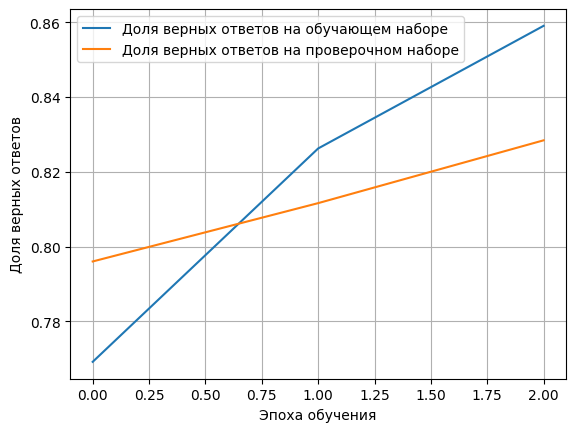

In [ ]:
plt.plot(history_SimpleRNN.history['accuracy'],
         label='Доля верных ответов на обучающем наборе')
plt.plot(history_SimpleRNN.history['val_accuracy'],
         label='Доля верных ответов на проверочном наборе')
plt.xlabel('Эпоха обучения')
plt.ylabel('Доля верных ответов')
plt.legend()
plt.grid()
plt.show()

## Распознаем данные из тестового набора(dence)



In [ ]:
# Оцениваем качество обучения сети на тестовых данных
scores = model.evaluate(x_test, y_test, verbose=0)
print("Точность работы на тестовых данных: %.2f%%" % (scores[1]*100))

Точность работы на тестовых данных: 84.41%


In [ ]:
predictions = model.predict(x_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
predictions[:5]

array([[0.00563907],
       [0.99953264],
       [0.8321611 ],
       [0.06441981],
       [0.9969668 ]], dtype=float32)

Округляем до 0 или 1

In [ ]:
predictions = predictions.round()

In [ ]:
predictions

array([[0.],
       [1.],
       [1.],
       ...,
       [0.],
       [0.],
       [0.]], dtype=float32)

## Распознаем данные из тестового набора(SimpleRNN)



In [ ]:
scores = model_SimpleRNN.evaluate(x_test, y_test, verbose=0)
print("Точность работы на тестовых данных: %.2f%%" % (scores[1]*100))

Точность работы на тестовых данных: 82.53%


In [ ]:
predictions = model_SimpleRNN.predict(x_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step


In [ ]:
predictions[:5]

array([[0.17706995],
       [0.9133237 ],
       [0.5781454 ],
       [0.88356864],
       [0.85480964]], dtype=float32)

In [ ]:
predictions = predictions.round()

In [ ]:
predictions

array([[0.],
       [1.],
       [1.],
       ...,
       [0.],
       [0.],
       [1.]], dtype=float32)

In [ ]:
# Звездные войны (положительный отзыв)
test_positiv = ''' "Star Wars: Skywalker. Sunrise" - I liked the movie. Compared to the 8th part of "Star Wars: The Last Jedi", the 9th part of Sunrise turned out to be more interesting. J.J. Abrams can be said to have completed the trilogy with dignity.
If you haven't watched this movie, then there will be spoilers!!!
Yes, there are disadvantages in this trilogy from J.J. Abrams, you can see he tried, he had big ideas, and wanted to develop different storylines, he wanted to make the trilogy more gloomy, but Disney forbade him. Of the zero trilogies from Lucas, I don't like the 2nd part, of the new trilogy, I don't like the 8th part. Let's be honest, whatever star wars there were, we'll miss the lightsaber battle, the Jedi, and the forces.
What about "Star Wars: Skywalker. Sunrise" yes, the film slightly copies the 6th part of Star Wars. I didn't see such big holes in the plot, there is one small unexpected twist in the film, but it is quickly eliminated (I'm talking about a spy). In the final, we finally got the answer to who Rey was, someone guessed but couldn't guess 100% for sure. All the trilogies revolve around the same Skywalker family and around Palpatine, because he participated in every trilogy.
The action is not bad in the movie, the visuals are great. What happened in the original from Lucas, and in this trilogy, Palpatine was handled too quickly and easily, I just expected more. It was nice to see the old characters from the universe. There were a lot of references. Many people were annoyed by Ben's character, to be honest, I liked him right away in the 7th film, he annoyed everyone because in the 7th film he wanted to become like Darth Vader, and in the 8th film he already helps Rey. I think he had an internal struggle between good and evil, where good took over. After all, o did exactly as his grandfather Vader did, and Ben died in the finale and left in the force, that he saved Rey, just as his grandfather once saved his son from Palpatine's death. It was especially pleasant to hear the voices of all the Jedi: Luke Skywalker, Obi-Wan, Qui-Gon, Yoda, Anakin Skywalker, Ley. And the movie ends on the planet where it all began on Tatooine. '''

In [ ]:
# Во все тяжкие (отрицательный отзыв)
test_negative = '''I will try to explain why I did not like the series. The idea is great! The main storyline and idea are brilliant. And the series in the first season is like, but then terribly annoying and does not allow to enjoy the ways of developing the storyline. Abnormal, inadequate and incomprehensible behavior of the characters of the second plan. Those very moments that move the plot and turn it in a new direction. I understand that these plot shifts, the writers and directors add the sharpness of the plots, to hook the audience. And they succeed, but the emotions remain negative. The wife is inappropriate, and the monologues are extremely sparse and unrefined at important plot points. The characters' actions are forced and lack intelligence. It looks like this: "We didn't succeed, so tell me where to find him. - I don't know. - Okay, I'll find him myself." "I don't believe in such dialogues. It's impossible for everyone to be so stupid. It doesn't happen in real life.These are the emotions that the series evokes, starting with season 3, when such things happen again and. '''

In [ ]:
# Большая ржака (нейтральынй отзыв)
test_neutral = ''' "Big Rucka" is all about the lost but definitely existing Kolchak gold. The main characters are two TV show hosts from a small town, and they don't know where they got the idea from, but they're determined to create their own reality show, become famous, and then move to Moscow to take over the show from Urgant or Malakhov. However , things don't go as planned, and a group of people starts chasing after the gold. What's happening to them is, of course, hilarious and trashy, you can't make it up on purpose - drinking on trains, planes, "Putin's sparrows", pregnant brides in the person of Semenovich... You understand that it's some kind of horror, but you're sitting there laughing. And it seems like everything is in its place - KVN players and 6ti-kadrovtsy, well, where else should they play? In short, to sum up: there is no special point in "Big Rzhak", the jokes are flat, simple, understandable to everyone, the actors are recognizable (and maybe someone even likes to look at the fat and curly guys Eugene from the "County Town", well, and everyone loves watching Annushka Semenovich '''

In [ ]:
# re.sub(pattern, repl, string, max=0)
# метод заменяет все вхождения pattern в string на repl, если не указано на max. Он возвращает измененную строку.
import re
test_positiv = re.sub('[,.\n]', ' ', test_positiv)
test_negative = re.sub('[,.\n]', ' ', test_negative)
test_neutral = re.sub('[,.\n]', ' ', test_neutral)


In [ ]:
test_positiv = test_positiv.lower()
test_negative = test_negative.lower()
test_neutral = test_neutral.lower()

In [ ]:
test_positiv

' "star wars: skywalker  sunrise" - i liked the movie  compared to the 8th part of "star wars: the last jedi"  the 9th part of sunrise turned out to be more interesting  j j  abrams can be said to have completed the trilogy with dignity  if you haven\'t watched this movie  then there will be spoilers!!! yes  there are disadvantages in this trilogy from j j  abrams  you can see he tried  he had big ideas  and wanted to develop different storylines  he wanted to make the trilogy more gloomy  but disney forbade him  of the zero trilogies from lucas  i don\'t like the 2nd part  of the new trilogy  i don\'t like the 8th part  let\'s be honest  whatever star wars there were  we\'ll miss the lightsaber battle  the jedi  and the forces  what about "star wars: skywalker  sunrise" yes  the film slightly copies the 6th part of star wars  i didn\'t see such big holes in the plot  there is one small unexpected twist in the film  but it is quickly eliminated (i\'m talking about a spy)  in the final 

In [ ]:
test_negative

'i will try to explain why i did not like the series  the idea is great! the main storyline and idea are brilliant  and the series in the first season is like  but then terribly annoying and does not allow to enjoy the ways of developing the storyline  abnormal  inadequate and incomprehensible behavior of the characters of the second plan  those very moments that move the plot and turn it in a new direction  i understand that these plot shifts  the writers and directors add the sharpness of the plots  to hook the audience  and they succeed  but the emotions remain negative  the wife is inappropriate  and the monologues are extremely sparse and unrefined at important plot points  the characters\' actions are forced and lack intelligence  it looks like this: "we didn\'t succeed  so tell me where to find him  - i don\'t know  - okay  i\'ll find him myself " "i don\'t believe in such dialogues  it\'s impossible for everyone to be so stupid  it doesn\'t happen in real life these are the emo

In [ ]:
test_neutral

' "big rucka" is all about the lost but definitely existing kolchak gold  the main characters are two tv show hosts from a small town  and they don\'t know where they got the idea from  but they\'re determined to create their own reality show  become famous  and then move to moscow to take over the show from urgant or malakhov  however   things don\'t go as planned  and a group of people starts chasing after the gold  what\'s happening to them is  of course  hilarious and trashy  you can\'t make it up on purpose - drinking on trains  planes  "putin\'s sparrows"  pregnant brides in the person of semenovich    you understand that it\'s some kind of horror  but you\'re sitting there laughing  and it seems like everything is in its place - kvn players and 6ti-kadrovtsy  well  where else should they play? in short  to sum up: there is no special point in "big rzhak"  the jokes are flat  simple  understandable to everyone  the actors are recognizable (and maybe someone even likes to look at 

In [ ]:
test_positiv = test_positiv.split(' ')
test_negative = test_negative.split(' ')
test_neutral = test_neutral.split(' ')

In [ ]:
test_positiv

['',
 '"star',
 'wars:',
 'skywalker',
 '',
 'sunrise"',
 '-',
 'i',
 'liked',
 'the',
 'movie',
 '',
 'compared',
 'to',
 'the',
 '8th',
 'part',
 'of',
 '"star',
 'wars:',
 'the',
 'last',
 'jedi"',
 '',
 'the',
 '9th',
 'part',
 'of',
 'sunrise',
 'turned',
 'out',
 'to',
 'be',
 'more',
 'interesting',
 '',
 'j',
 'j',
 '',
 'abrams',
 'can',
 'be',
 'said',
 'to',
 'have',
 'completed',
 'the',
 'trilogy',
 'with',
 'dignity',
 '',
 'if',
 'you',
 "haven't",
 'watched',
 'this',
 'movie',
 '',
 'then',
 'there',
 'will',
 'be',
 'spoilers!!!',
 'yes',
 '',
 'there',
 'are',
 'disadvantages',
 'in',
 'this',
 'trilogy',
 'from',
 'j',
 'j',
 '',
 'abrams',
 '',
 'you',
 'can',
 'see',
 'he',
 'tried',
 '',
 'he',
 'had',
 'big',
 'ideas',
 '',
 'and',
 'wanted',
 'to',
 'develop',
 'different',
 'storylines',
 '',
 'he',
 'wanted',
 'to',
 'make',
 'the',
 'trilogy',
 'more',
 'gloomy',
 '',
 'but',
 'disney',
 'forbade',
 'him',
 '',
 'of',
 'the',
 'zero',
 'trilogies',
 'from',


In [ ]:
test_negative

['i',
 'will',
 'try',
 'to',
 'explain',
 'why',
 'i',
 'did',
 'not',
 'like',
 'the',
 'series',
 '',
 'the',
 'idea',
 'is',
 'great!',
 'the',
 'main',
 'storyline',
 'and',
 'idea',
 'are',
 'brilliant',
 '',
 'and',
 'the',
 'series',
 'in',
 'the',
 'first',
 'season',
 'is',
 'like',
 '',
 'but',
 'then',
 'terribly',
 'annoying',
 'and',
 'does',
 'not',
 'allow',
 'to',
 'enjoy',
 'the',
 'ways',
 'of',
 'developing',
 'the',
 'storyline',
 '',
 'abnormal',
 '',
 'inadequate',
 'and',
 'incomprehensible',
 'behavior',
 'of',
 'the',
 'characters',
 'of',
 'the',
 'second',
 'plan',
 '',
 'those',
 'very',
 'moments',
 'that',
 'move',
 'the',
 'plot',
 'and',
 'turn',
 'it',
 'in',
 'a',
 'new',
 'direction',
 '',
 'i',
 'understand',
 'that',
 'these',
 'plot',
 'shifts',
 '',
 'the',
 'writers',
 'and',
 'directors',
 'add',
 'the',
 'sharpness',
 'of',
 'the',
 'plots',
 '',
 'to',
 'hook',
 'the',
 'audience',
 '',
 'and',
 'they',
 'succeed',
 '',
 'but',
 'the',
 'emot

In [ ]:
test_neutral

['',
 '"big',
 'rucka"',
 'is',
 'all',
 'about',
 'the',
 'lost',
 'but',
 'definitely',
 'existing',
 'kolchak',
 'gold',
 '',
 'the',
 'main',
 'characters',
 'are',
 'two',
 'tv',
 'show',
 'hosts',
 'from',
 'a',
 'small',
 'town',
 '',
 'and',
 'they',
 "don't",
 'know',
 'where',
 'they',
 'got',
 'the',
 'idea',
 'from',
 '',
 'but',
 "they're",
 'determined',
 'to',
 'create',
 'their',
 'own',
 'reality',
 'show',
 '',
 'become',
 'famous',
 '',
 'and',
 'then',
 'move',
 'to',
 'moscow',
 'to',
 'take',
 'over',
 'the',
 'show',
 'from',
 'urgant',
 'or',
 'malakhov',
 '',
 'however',
 '',
 '',
 'things',
 "don't",
 'go',
 'as',
 'planned',
 '',
 'and',
 'a',
 'group',
 'of',
 'people',
 'starts',
 'chasing',
 'after',
 'the',
 'gold',
 '',
 "what's",
 'happening',
 'to',
 'them',
 'is',
 '',
 'of',
 'course',
 '',
 'hilarious',
 'and',
 'trashy',
 '',
 'you',
 "can't",
 'make',
 'it',
 'up',
 'on',
 'purpose',
 '-',
 'drinking',
 'on',
 'trains',
 '',
 'planes',
 '',
 '"put

Кодирем текст

In [ ]:
coded_text_negative = [1]
for word in test_negative:
    if word != '':
        word_code = word_index.get(word, 2)
        if word_code > num_words:
            word_code = 2
        if word_code != 2:
          word_code += 3
        coded_text_negative.append(word_code)
test_negative = coded_text_negative

In [ ]:
coded_text_positiv = [1]
for word in test_positiv:
    if word != '':
        word_code = word_index.get(word, 2)
        if word_code > num_words:
            word_code = 2
        if word_code != 2:
          word_code += 3
        coded_text_positiv.append(word_code)
test_positiv = coded_text_positiv


In [ ]:
coded_text_neutral = [1]
for word in test_neutral:
    if word != '':
        word_code = word_index.get(word, 2)
        if word_code > num_words:
            word_code = 2
        if word_code != 2:
          word_code += 3
        coded_text_neutral.append(word_code)
test_neutral = coded_text_neutral

In [ ]:
print(coded_text_positiv)

[1, 2, 2, 9766, 2, 2, 13, 423, 4, 20, 1079, 8, 4, 10549, 173, 7, 2, 2, 4, 236, 2, 4, 15316, 173, 7, 6985, 679, 46, 8, 30, 53, 221, 1468, 1468, 2, 70, 30, 301, 8, 28, 5645, 4, 2355, 19, 3764, 48, 25, 774, 296, 14, 20, 95, 50, 80, 30, 2, 422, 50, 26, 2, 11, 14, 2355, 39, 1468, 1468, 2, 25, 70, 67, 29, 805, 29, 69, 194, 1008, 2, 473, 8, 2061, 275, 14273, 29, 473, 8, 97, 4, 2355, 53, 7368, 21, 910, 2, 90, 7, 4, 1456, 2, 39, 3651, 13, 92, 40, 4, 3975, 173, 7, 4, 162, 2355, 13, 92, 40, 4, 10549, 173, 903, 30, 1202, 845, 323, 1650, 50, 71, 3899, 717, 4, 2, 985, 4, 6326, 2, 4, 1929, 51, 44, 2, 2, 9766, 2, 422, 4, 22, 1076, 4651, 4, 10915, 173, 7, 323, 1650, 13, 161, 67, 141, 194, 1512, 11, 4, 114, 50, 9, 31, 392, 2076, 1009, 11, 4, 22, 21, 12, 9, 946, 9751, 2, 662, 44, 6, 2, 11, 4, 477, 75, 417, 188, 4, 1527, 8, 37, 18729, 16, 294, 4335, 21, 426, 482, 2, 18, 252, 32, 4, 2, 11093, 187, 4, 172, 9766, 223, 2, 187, 2, 88, 29, 12984, 11, 175, 2355, 4, 206, 9, 24, 78, 11, 4, 20, 4, 2057, 26, 87, 51,

In [ ]:
print(coded_text_negative)

[1, 13, 80, 353, 8, 1260, 138, 13, 122, 24, 40, 4, 201, 4, 326, 9, 2, 4, 293, 769, 2, 326, 26, 530, 2, 4, 201, 11, 4, 86, 811, 9, 40, 21, 95, 1905, 616, 2, 127, 24, 1741, 8, 358, 4, 771, 7, 4240, 4, 769, 18950, 13170, 2, 4709, 2003, 7, 4, 105, 7, 4, 333, 1347, 148, 55, 388, 15, 847, 4, 114, 2, 471, 12, 11, 6, 162, 458, 13, 391, 15, 134, 114, 7038, 4, 927, 2, 907, 763, 4, 2, 7, 4, 1847, 8, 4357, 4, 311, 2, 36, 3115, 21, 4, 1438, 2416, 1566, 4, 322, 9, 4650, 2, 4, 8729, 26, 576, 9467, 2, 2, 33, 674, 114, 757, 4, 4395, 1729, 26, 918, 2, 583, 1663, 12, 272, 40, 2, 2, 161, 3115, 38, 376, 72, 121, 8, 169, 90, 2, 13, 92, 124, 2, 864, 637, 169, 90, 546, 2, 2, 92, 264, 11, 141, 3963, 45, 1167, 18, 316, 8, 30, 38, 379, 12, 152, 593, 11, 147, 113, 134, 26, 4, 1438, 15, 4, 201, 7630, 1861, 19, 811, 342, 54, 141, 183, 593, 174, 2]


In [ ]:
print(coded_text_neutral)

[1, 2, 2, 9, 32, 44, 4, 416, 21, 407, 7433, 5913, 1818, 4, 293, 105, 26, 107, 248, 123, 10121, 39, 6, 392, 513, 2, 36, 92, 124, 121, 36, 188, 4, 326, 39, 21, 507, 2930, 8, 987, 68, 205, 635, 123, 413, 804, 2, 95, 847, 8, 18347, 8, 193, 120, 4, 123, 39, 2, 42, 2, 190, 183, 92, 140, 17, 4261, 2, 6, 604, 7, 84, 517, 3187, 103, 4, 1818, 803, 1448, 8, 98, 9, 7, 265, 642, 2, 4373, 25, 191, 97, 12, 56, 23, 1288, 2, 2779, 23, 6900, 7061, 2, 2, 2755, 7562, 11, 4, 415, 7, 2, 25, 391, 15, 45, 49, 243, 7, 189, 21, 335, 1266, 50, 1104, 2, 12, 186, 40, 285, 9, 11, 94, 273, 2, 2, 1850, 2, 2, 73, 121, 334, 144, 36, 2, 11, 346, 8, 3040, 2, 50, 9, 57, 318, 213, 11, 2, 2, 4, 640, 26, 1035, 606, 4394, 8, 316, 4, 156, 26, 5710, 2, 279, 294, 60, 1232, 8, 168, 33, 4, 1922, 2, 5620, 493, 5090, 39, 4, 2, 2, 73, 2, 316, 1388, 149, 2, 2]


Преобразуем текст в массив numpy

In [ ]:
x_positive = np.array(coded_text_positiv)
x_negative = np.array(coded_text_negative)
x_neutral = np.array(coded_text_neutral)

In [ ]:
x_positive = np.expand_dims(x_positive, axis=0)
x_negative = np.expand_dims(x_negative, axis=0)
x_neutral = np.expand_dims(x_neutral, axis=0)

In [ ]:
x_negative.shape

(1, 190)

In [ ]:
x_positive.shape

(1, 395)

In [ ]:
x_neutral.shape

(1, 190)

In [ ]:
x_positive = pad_sequences(x_positive, maxlen=maxlen)
x_negative = pad_sequences(x_negative, maxlen=maxlen)
x_neutral = pad_sequences(x_neutral, maxlen=maxlen)

#Работа моделей:

#Модель Dense:

In [ ]:
predictions = model.predict(x_positive)
print(predictions)
predictions.round()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
[[0.47989717]]


array([[0.]], dtype=float32)

In [ ]:
predictions = model.predict(x_negative)
print(predictions)
predictions.round()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
[[0.03644794]]


array([[0.]], dtype=float32)

In [ ]:
predictions = model.predict(x_neutral)
print(predictions)
predictions.round()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
[[0.00231861]]


array([[0.]], dtype=float32)

#Модель SimpleRNN

In [ ]:
predictions = model_SimpleRNN.predict(x_positive)
print(predictions)
predictions.round()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
[[0.84185815]]


array([[1.]], dtype=float32)

In [ ]:
predictions = model_SimpleRNN.predict(x_negative)
print(predictions)
predictions.round()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
[[0.8204294]]


array([[1.]], dtype=float32)

In [ ]:
predictions = model_SimpleRNN.predict(x_neutral)
print(predictions)
predictions.round()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
[[0.371121]]


array([[0.]], dtype=float32)

In [ ]:
print("Структура модели Dense")
model.summary()
print("\nСтруктура модели SimpleRNN")
model_SimpleRNN.summary()

Структура модели Dense


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 200, 50)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 10000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 5)              │        50,005 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,100,024 (8.01 MB)

 Trainable params: 1,050,011 (4.01 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ (None, 200, 50)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 3)              │           162 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,334 (7.63 MB)

 Trainable params: 1,000,166 (3.82 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,000,168 (3.82 MB)